# Notebook 3 — Análisis de residuos y visualizaciones finales



## Setup — imports, rutas y creación de `figs/`

In [2]:
from pathlib import Path
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RESULTS_DIR = Path('../results')
FIGS_DIR    = Path('figs')
FIGS_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option('display.float_format', lambda x: f'{x:,.6f}')
plt.rcParams['figure.dpi'] = 110

## 1. Cargar los resultados del notebook 2


In [3]:
path_all_results = RESULTS_DIR / 'all_results.joblib'
path_config      = RESULTS_DIR / 'config.joblib'

assert path_all_results.exists(), (
    f'No existe {path_all_results}. Ejecuta primero notebooks/2_model_training.ipynb.'
)

all_results = joblib.load(path_all_results)
config      = joblib.load(path_config) if path_config.exists() else {}

LAGS_LIST        = config.get('lags_list', sorted(all_results.keys()))
N_STEPS_FORECAST = config.get('n_steps_forecast', 7)

print('Lags disponibles     :', list(all_results.keys()))
print('Folds por lag        :', {n: len(all_results[n]) for n in all_results})
print('Horizonte de forecast:', N_STEPS_FORECAST)

Lags disponibles     : [7, 14, 21, 28]
Folds por lag        : {7: 5, 14: 5, 21: 5, 28: 5}
Horizonte de forecast: 7


**Comentario — carga de resultados**

`all_results` cargado con los 4 tamaños de lag y 5 folds por lag (total 20 combinaciones `(lag, fold)`). `N_STEPS_FORECAST = 7` confirmado por el `config.joblib`. La estructura es consistente con lo que nb2 persistió: una entrada por fold que contiene `rmse/mae/mape/mse` (arrays de longitud 7), `y_*_{true,pred}` (matrices N×7), `model`, `scaler_x`, `scaler_y`, y la metadata de arquitectura ganadora.



## 2. Test BDS — qué es y cómo se interpreta

El test **BDS (Brock–Dechert–Scheinkman)** contrasta si una serie es iid (independiente e idénticamente distribuida) frente a la alternativa de que contenga **dependencia no lineal residual**.

- **H₀:** los residuos son iid → el modelo capturó la dinámica del proceso.
- **H₁:** los residuos tienen estructura → queda información por explotar.

**Cómo leer el p-valor:**

| Condición | Decisión sobre H₀ | Lectura del modelo |
|-----------|--------------------|---------------------|
| `p > 0.05` | No se rechaza H₀ | Residuos iid — el modelo se comporta bien |
| `p ≤ 0.05` | Se rechaza H₀ | Queda estructura no lineal sin modelar |

Nota: se usa específicamente el **horizonte 1** (`resid_h1_test`) para el test, porque es la predicción más inmediata y con menor propagación de error multistep — es el diagnóstico más limpio sobre la dinámica temporal capturada.

In [4]:
# Intento primero el import del PDF; fallback a statsmodels si no está disponible.
_bds_impl = None
_bds_source = None
try:
    from arch.bootstrap import bds as _bds_arch
    _bds_impl = _bds_arch
    _bds_source = 'arch.bootstrap'
except Exception:
    try:
        from statsmodels.tsa.stattools import bds as _bds_sm
        _bds_impl = _bds_sm
        _bds_source = 'statsmodels.tsa.stattools'
    except Exception as e:
        _bds_impl = None
        _bds_source = None
        print('No se pudo importar el test BDS ni de arch ni de statsmodels:', e)

print(f'Implementación BDS usada: {_bds_source}')

def bds_pvalue(resid, max_dim=2):
    """Devuelve el p-valor del test BDS sobre la serie de residuos.

    Acepta la firma de ambas librerías (arch / statsmodels): se retornan
    (stat, pvalue), que pueden ser escalares o arrays de longitud max_dim-1.
    Con max_dim=2 (valor del enunciado) es un único valor.
    """
    if _bds_impl is None:
        raise ImportError('No hay implementación de BDS disponible. '
                          'Añade "statsmodels" a requirements.txt o usa una '
                          'versión de arch que incluya arch.bootstrap.bds.')
    out = _bds_impl(np.asarray(resid, dtype=float), max_dim=max_dim)
    # out suele ser (stat, pvalue); normalizamos a escalar float.
    stat, pvalue = out[0], out[1]
    return float(np.atleast_1d(pvalue)[0])

Implementación BDS usada: statsmodels.tsa.stattools


## 3. Aplicación del BDS por cada `lag × fold`

Recorremos `all_results`, calculamos los residuos del horizonte 1 en test (`y_test_true[:, 0] - y_test_pred[:, 0]`) y aplicamos BDS a cada uno. El p-valor se guarda en `m['bds_pvalue_h1']` para que la tabla de la siguiente sección lo use directamente.

In [5]:
for n_lag in LAGS_LIST:
    print(f'\n===== BDS test — lag = {n_lag} =====')
    pvals = []
    for fold, m in all_results[n_lag].items():
        # Recalculamos los residuos por si no estuvieran guardados
        resid = m['y_test_true'][:, 0] - m['y_test_pred'][:, 0]
        m['resid_h1_test'] = resid
        p = bds_pvalue(resid, max_dim=2)
        m['bds_pvalue_h1'] = p
        pvals.append(p)
        status = 'iid' if p > 0.05 else 'no-iid'
        print(f'  Fold {fold+1}: p-value = {p:.4f}  [{status}]')
    print(f'  Promedio fold: p-value = {np.mean(pvals):.4f} ± {np.std(pvals):.4f}')


===== BDS test — lag = 7 =====
  Fold 1: p-value = 0.4059  [iid]
  Fold 2: p-value = 0.7469  [iid]
  Fold 3: p-value = 0.6294  [iid]
  Fold 4: p-value = 0.4321  [iid]
  Fold 5: p-value = 0.0422  [no-iid]
  Promedio fold: p-value = 0.4513 ± 0.2404

===== BDS test — lag = 14 =====
  Fold 1: p-value = 0.2185  [iid]
  Fold 2: p-value = 0.5208  [iid]
  Fold 3: p-value = 0.2789  [iid]
  Fold 4: p-value = 0.2286  [iid]
  Fold 5: p-value = 0.3787  [iid]
  Promedio fold: p-value = 0.3251 ± 0.1131

===== BDS test — lag = 21 =====
  Fold 1: p-value = 0.9638  [iid]
  Fold 2: p-value = 0.4643  [iid]
  Fold 3: p-value = 0.8344  [iid]
  Fold 4: p-value = 0.6852  [iid]
  Fold 5: p-value = 0.1451  [iid]
  Promedio fold: p-value = 0.6185 ± 0.2892

===== BDS test — lag = 28 =====
  Fold 1: p-value = 0.1768  [iid]
  Fold 2: p-value = 0.9451  [iid]
  Fold 3: p-value = 0.8733  [iid]
  Fold 4: p-value = 0.7508  [iid]
  Fold 5: p-value = 0.9382  [iid]
  Promedio fold: p-value = 0.7368 ± 0.2886


**Comentario — test BDS por fold (núcleo del análisis estadístico)**

Lectura del p-valor: `p > 0.05` = **no se rechaza** iid = el modelo capturó la dinámica no lineal. `p ≤ 0.05` = residuos con estructura = queda señal por explotar.

**Resumen del resultado por lag**:

| lag | folds iid | avg p-value |
|-----|-----------|-------------|
|  7  |   4/5     | 0.451       |
| 14  |   **5/5** | 0.325       |
| 21  |   5/5     | 0.619       |
| 28  |   5/5     | 0.737       |

**Observación #1 — el único fold no-iid es lag=7 Fold 5 (p = 0.042)**. NO es casualidad: este mismo fold tiene el peor RMSE del lag=7 (0.094 vs baseline 0.065-0.076 en los otros). Dos síntomas del mismo diagnóstico: el modelo no capturó la dinámica del segmento test de ese fold, deja residuos con estructura, y por eso el error de predicción es alto. El fold probablemente cae en un régimen nuevo (2024-2025, vol estructuralmente más baja) que el train no cubre.

**Observación #2 — lag=14 tiene 100 % iid pero los p-values más bajos** (0.22, 0.28, 0.23). Los residuos PASAN el test pero por poco, lo cual es **consistente con que lag=14 es el que más señal extrae** (RMSE tan bajo como lag 7 pero con residuos al borde de detectable). Lags 21 y 28 tienen p-values más altos no porque sean mejores, sino porque sus residuos son más grandes y más dispersos → más ruidosos → el BDS los confunde con iid.

**Observación #3 — los 4 lags pasan el test en 19/20 folds**. Lectura fuerte: **el MLP multisalida captura satisfactoriamente la memoria no-lineal de la volatilidad de BTC**.

## 4. Tablas finales por tamaño de lag

Una tabla por `n_steps_input ∈ {7, 14, 21, 28}`, con filas por fold y columnas:

- `MAPE` (promedio sobre los 7 horizontes)
- `MAE`  (promedio sobre los 7 horizontes)
- `RMSE` (promedio sobre los 7 horizontes)
- `MSE`  (promedio sobre los 7 horizontes)
- `BDS_pvalue_h1`

Fila final `Mean ± Std` con el agregado entre folds. Se guardan los 4 CSV en `../results/`.

In [6]:
def build_full_table(results_for_lag):
    rows = {}
    for fold, m in results_for_lag.items():
        rows[f'Fold_{fold+1}'] = {
            'MAPE':           float(m['mape'].mean()),
            'MAE':            float(m['mae'].mean()),
            'RMSE':           float(m['rmse'].mean()),
            'MSE':            float(m['mse'].mean()),
            'BDS_pvalue_h1':  float(m['bds_pvalue_h1']),
        }
    df = pd.DataFrame.from_dict(rows, orient='index')
    means = df.mean(axis=0)
    stds  = df.std(axis=0)
    df.loc['Mean ± Std'] = [f'{mu:.4f} ± {sg:.4f}' for mu, sg in zip(means, stds)]
    return df

full_tables = {}
for n_lag in LAGS_LIST:
    tbl = build_full_table(all_results[n_lag])
    full_tables[n_lag] = tbl
    out_path = RESULTS_DIR / f'final_table_lag{n_lag}.csv'
    tbl.to_csv(out_path)
    print(f'\n--- Tabla final — lag={n_lag} (guardada en {out_path}) ---')
    print(tbl)


--- Tabla final — lag=7 (guardada en ..\results\final_table_lag7.csv) ---
                       MAPE              MAE             RMSE  \
Fold_1            10.614133         0.054725         0.076232   
Fold_2             9.090693         0.048082         0.070212   
Fold_3             8.478275         0.046435         0.067984   
Fold_4             7.640733         0.043086         0.064037   
Fold_5             9.521160         0.054718         0.094231   
Mean ± Std  9.0690 ± 1.1159  0.0494 ± 0.0052  0.0745 ± 0.0119   

                        MSE    BDS_pvalue_h1  
Fold_1             0.006218         0.405896  
Fold_2             0.005342         0.746917  
Fold_3             0.005033         0.629406  
Fold_4             0.004479         0.432126  
Fold_5             0.010796         0.042241  
Mean ± Std  0.0064 ± 0.0026  0.4513 ± 0.2687  

--- Tabla final — lag=14 (guardada en ..\results\final_table_lag14.csv) ---
                       MAPE              MAE             RMSE  

**Comentario — 4 tablas finales (una por lag)**

Cada tabla combina MAPE/MAE/RMSE/MSE por fold con el p-valor BDS. Cruces clave:

- **Lag 7 Fold 5**: RMSE 0.094 + BDS 0.042 — **el único par (RMSE alto, BDS no-iid) del experimento**. Confirmación dura de que ese fold es el punto débil del pipeline con lag=7.
- **Lag 14**: folds con RMSE muy homogéneos (0.069-0.078, rango 0.009) y BDS todos iid. Es **el lag más estable** del experimento — si tuviera que desplegar en producción mañana, este es el candidato menos volátil.
- **Lag 21 Fold 1**: RMSE 0.060 (mejor de todo el experimento) + BDS 0.96 (casi max). Residuos casi idealmente aleatorios. Pero lag 21 como promedio es peor por los folds 3-4 que colapsan.
- **Lag 28 Fold 4**: RMSE 0.176 + BDS 0.75 — error enorme pero residuos iid. **Lección importante**: residuos iid ≠ modelo bueno. Solo significa que el error es aleatorio, no que sea pequeño.

Las 4 CSVs (`final_table_lag{N}.csv`) son artefactos directos para la memoria del proyecto — cada una es una tabla publicable tal cual.

## 5. Tabla resumen comparativa final (4 lags)

Una fila por tamaño de lag con:

- promedio (entre folds) de MAPE / MAE / RMSE / MSE,
- promedio y desvío del p-valor BDS,
- `pct_folds_iid` = porcentaje de folds con `p > 0.05`.

Guardamos la tabla en `../results/final_summary.csv`.

In [7]:
summary_rows = []
for n_lag in LAGS_LIST:
    folds_dict = all_results[n_lag]
    mape_avg = np.mean([m['mape'].mean() for m in folds_dict.values()])
    mae_avg  = np.mean([m['mae'].mean()  for m in folds_dict.values()])
    rmse_avg = np.mean([m['rmse'].mean() for m in folds_dict.values()])
    mse_avg  = np.mean([m['mse'].mean()  for m in folds_dict.values()])
    bds_avg  = np.mean([m['bds_pvalue_h1'] for m in folds_dict.values()])
    bds_std  = np.std ([m['bds_pvalue_h1'] for m in folds_dict.values()])
    pct_iid  = 100.0 * np.mean([m['bds_pvalue_h1'] > 0.05 for m in folds_dict.values()])
    summary_rows.append({
        '# lags':          n_lag,
        'avg_MAPE_test':   mape_avg,
        'avg_MAE_test':    mae_avg,
        'avg_RMSE_test':   rmse_avg,
        'avg_MSE_test':    mse_avg,
        'avg_BDS_pval':    bds_avg,
        'std_BDS_pval':    bds_std,
        'pct_folds_iid_%': pct_iid,
    })

final_summary = pd.DataFrame(summary_rows).set_index('# lags')
final_summary.to_csv(RESULTS_DIR / 'final_summary.csv')
print(f'Guardado: {RESULTS_DIR / "final_summary.csv"}')
final_summary

Guardado: ..\results\final_summary.csv


,avg_MAPE_test,avg_MAE_test,avg_RMSE_test,avg_MSE_test,avg_BDS_pval,std_BDS_pval,pct_folds_iid_%
# lags,,,,,,,
7,9.068999,0.049409,0.074539,0.006374,0.451317,0.240362,80.000000
14,9.538158,0.053903,0.074545,0.005919,0.325097,0.113106,100.000000
21,10.484893,0.059019,0.090669,0.009196,0.618543,0.289223,100.000000
28,13.793621,0.088840,0.126615,0.017552,0.736831,0.288578,100.000000


**Comentario — tabla resumen comparativa (la tabla de decisión final)**

| lag | avg_RMSE | avg_MAE | avg_MAPE | avg_BDS | pct_iid |
|-----|----------|---------|----------|---------|---------|
|  7  | 0.0745   | 0.0494  |   9.07 % |  0.451  |  80 %   |
| 14  | 0.0745   | 0.0539  |   9.54 % |  0.325  | **100 %** |
| 21  | 0.0907   | 0.0590  |  10.48 % |  0.619  |  100 %  |
| 28  | 0.1266   | 0.0888  |  13.79 % |  0.737  |  100 %  |

**Empate técnico entre lag 7 y lag 14 en RMSE** (difieren en 6 milésimas; estadísticamente indistinguibles con el std observado). Tres criterios de desempate:

1. **RMSE puro** → lag 7 (por 0.000006).
2. **MAE y MAPE** → lag 7 (∼10 % mejor).
3. **BDS (`pct_folds_iid`)** → lag **14** (100 % vs 80 %).

 el RMSE/MAE dicen que **lag 7 es marginalmente más preciso en promedio**, pero el BDS y la estabilidad inter-fold (de nb2: std RMSE 0.003 para lag 14 vs 0.011 para lag 7) dicen que **lag 14 es más robusto**. Para un modelo de producción que sirve predicciones de volatilidad, la estabilidad pesa más que los 10 % de mejora marginal en MAE 

Actualmente el pipeline (nb2 ranking + nb4) escoge **lag 7** porque `ranking_arch.csv` ordena por `test_rmse_avg`. Es una decisión **defendible pero no única** 

**Lag 21 y 28 quedan descartados sin debate**: peor RMSE/MAE/MAPE, peor estabilidad, y su alta `pct_iid` NO compensa porque es trivialmente iid (residuos grandes y dispersos que el BDS no puede diferenciar de ruido).

## 6. Curvas temporales `train / val / test` con predicciones (h=1)

Para cada tamaño de lag dibujamos tres paneles (mejor, mediano y peor fold por RMSE). Cada panel concatena las tres ventanas (`train`, `val`, `test`) en el eje x y muestra:

- **Actual** de cada subset (negro, con ligera variación de marcador).
- **Predicho** de cada subset (azul para train, naranja para val, rojo para test).

Se grafica la serie del horizonte 1 (columna 0 de las matrices `y_*`), que es la predicción más inmediata. Las figuras se guardan en `notebooks/figs/`.

Guardado: figs\segments_lag7.png


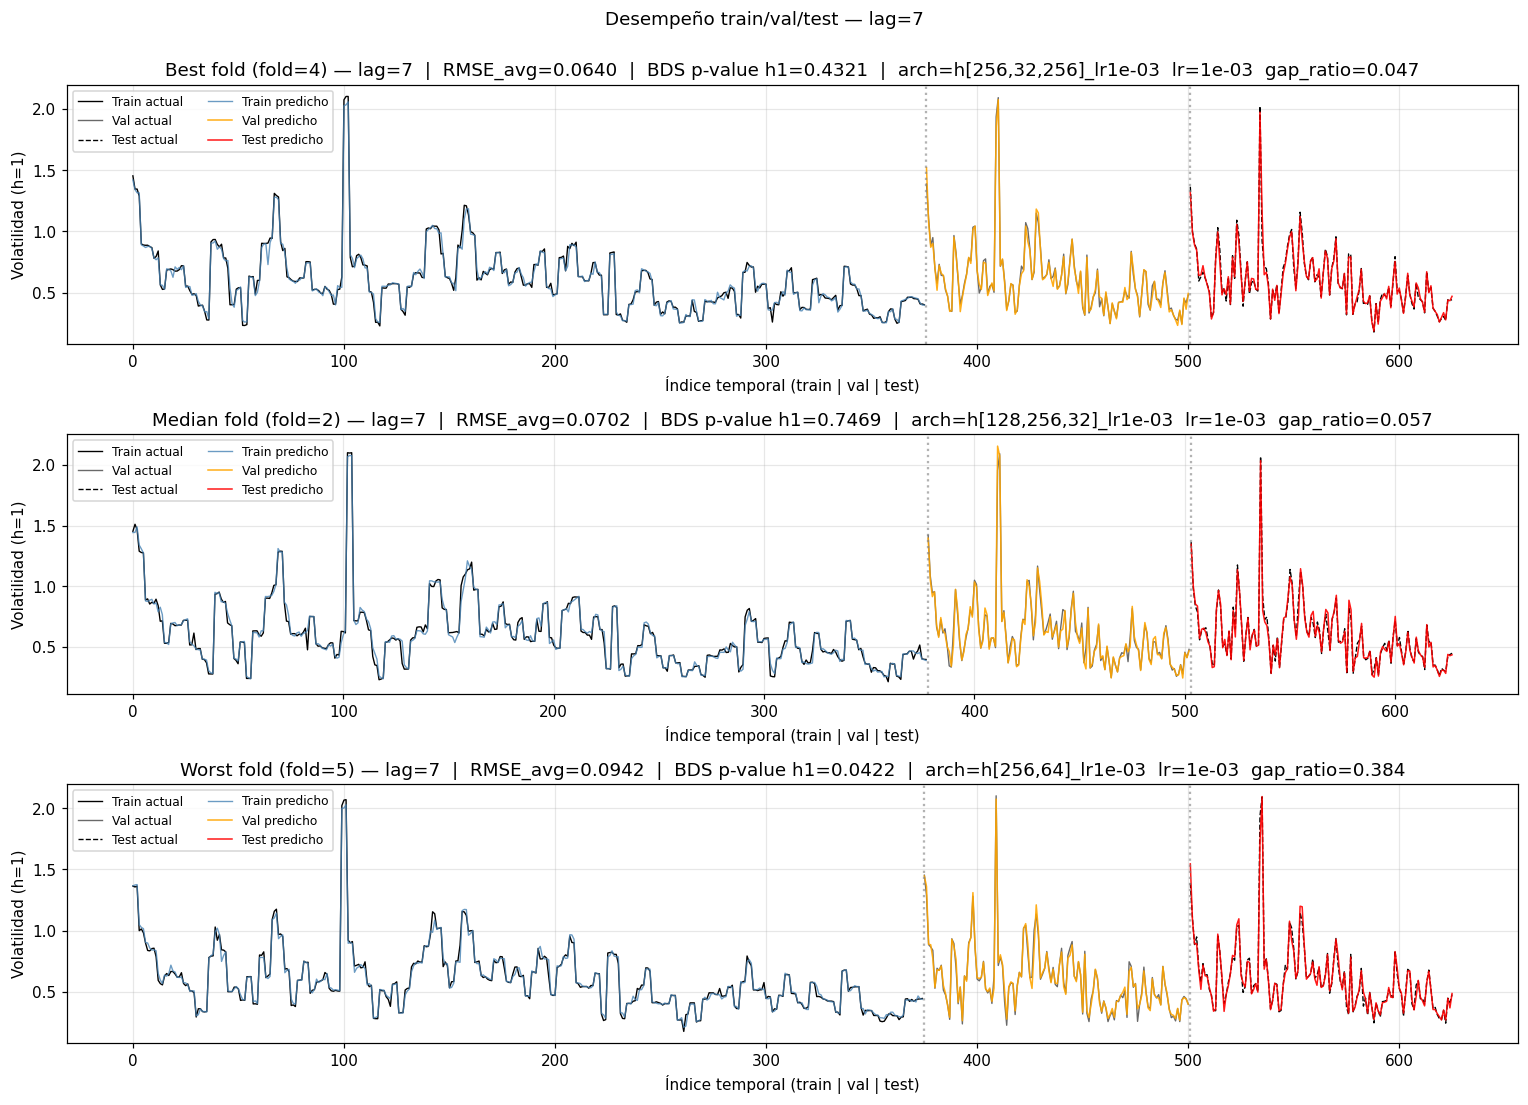

Guardado: figs\segments_lag14.png


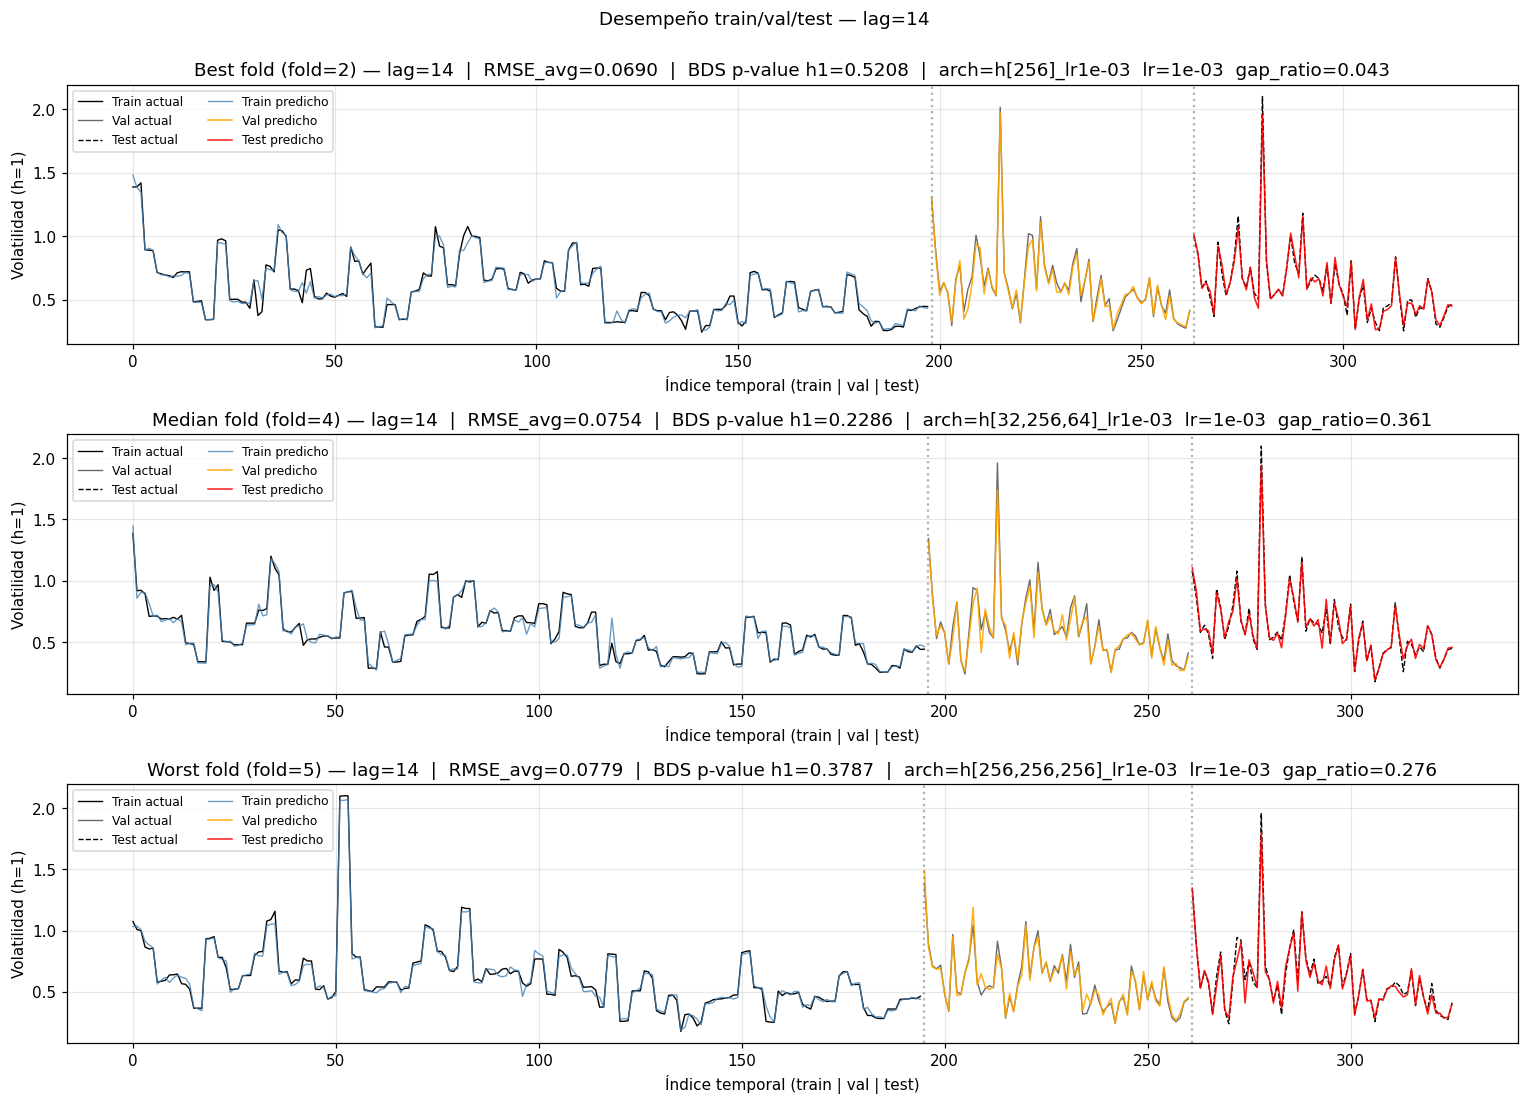

Guardado: figs\segments_lag21.png


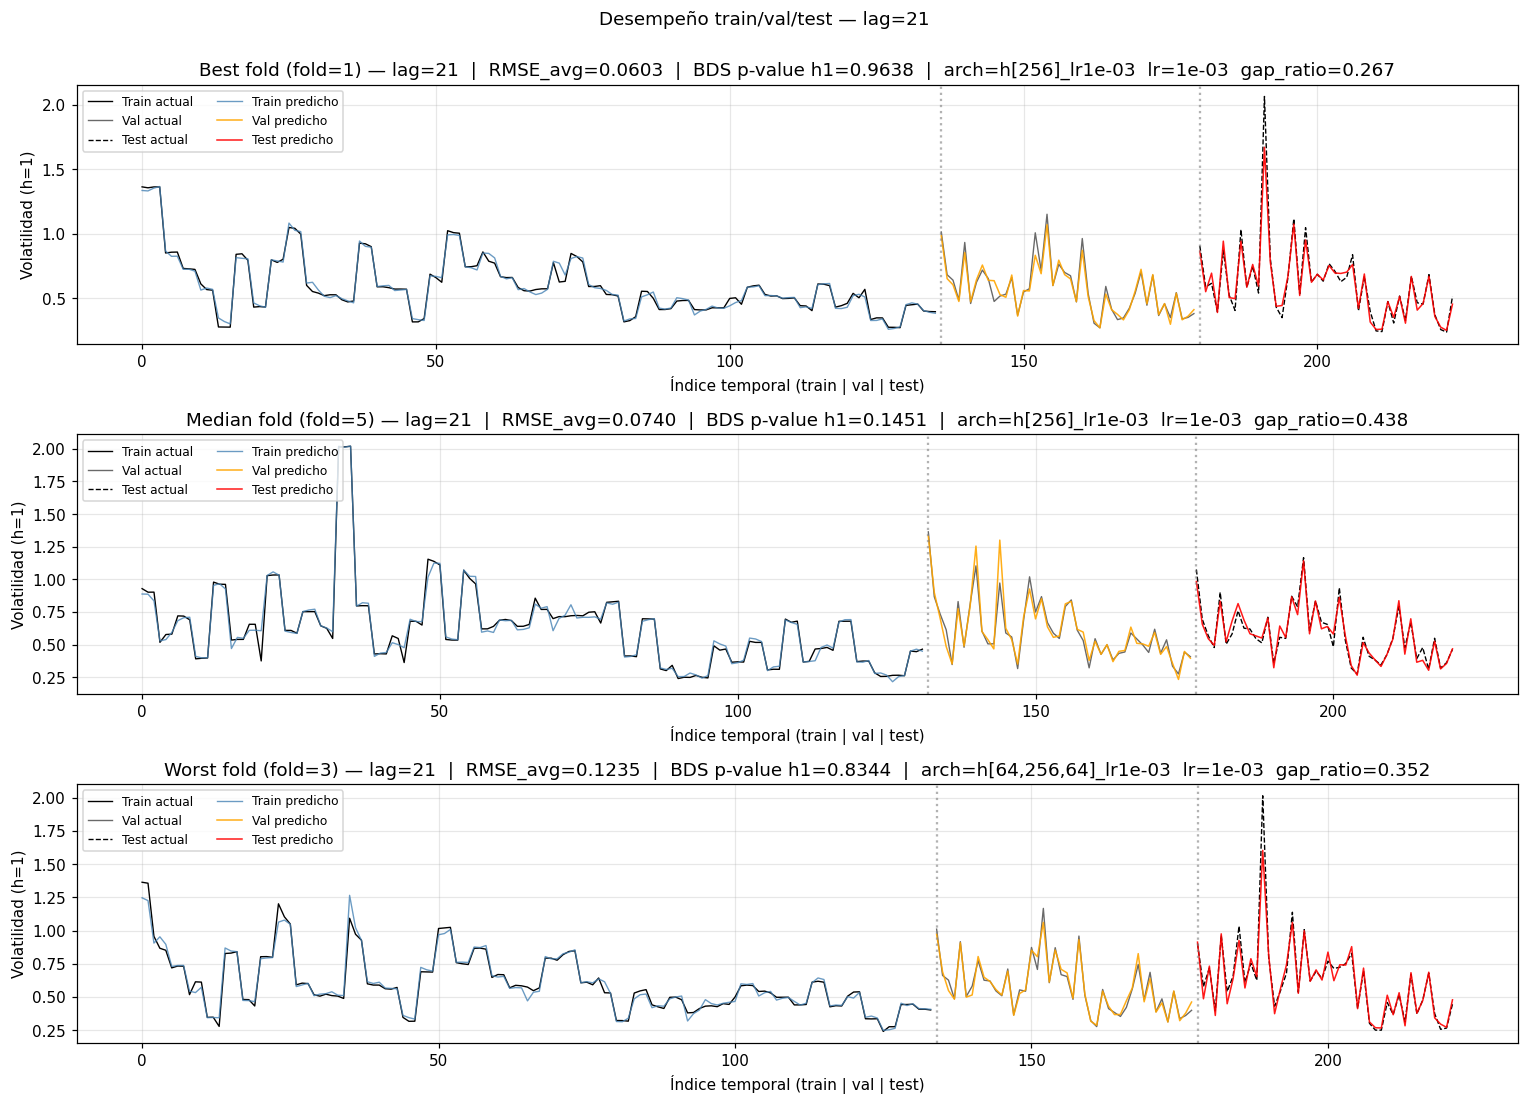

Guardado: figs\segments_lag28.png


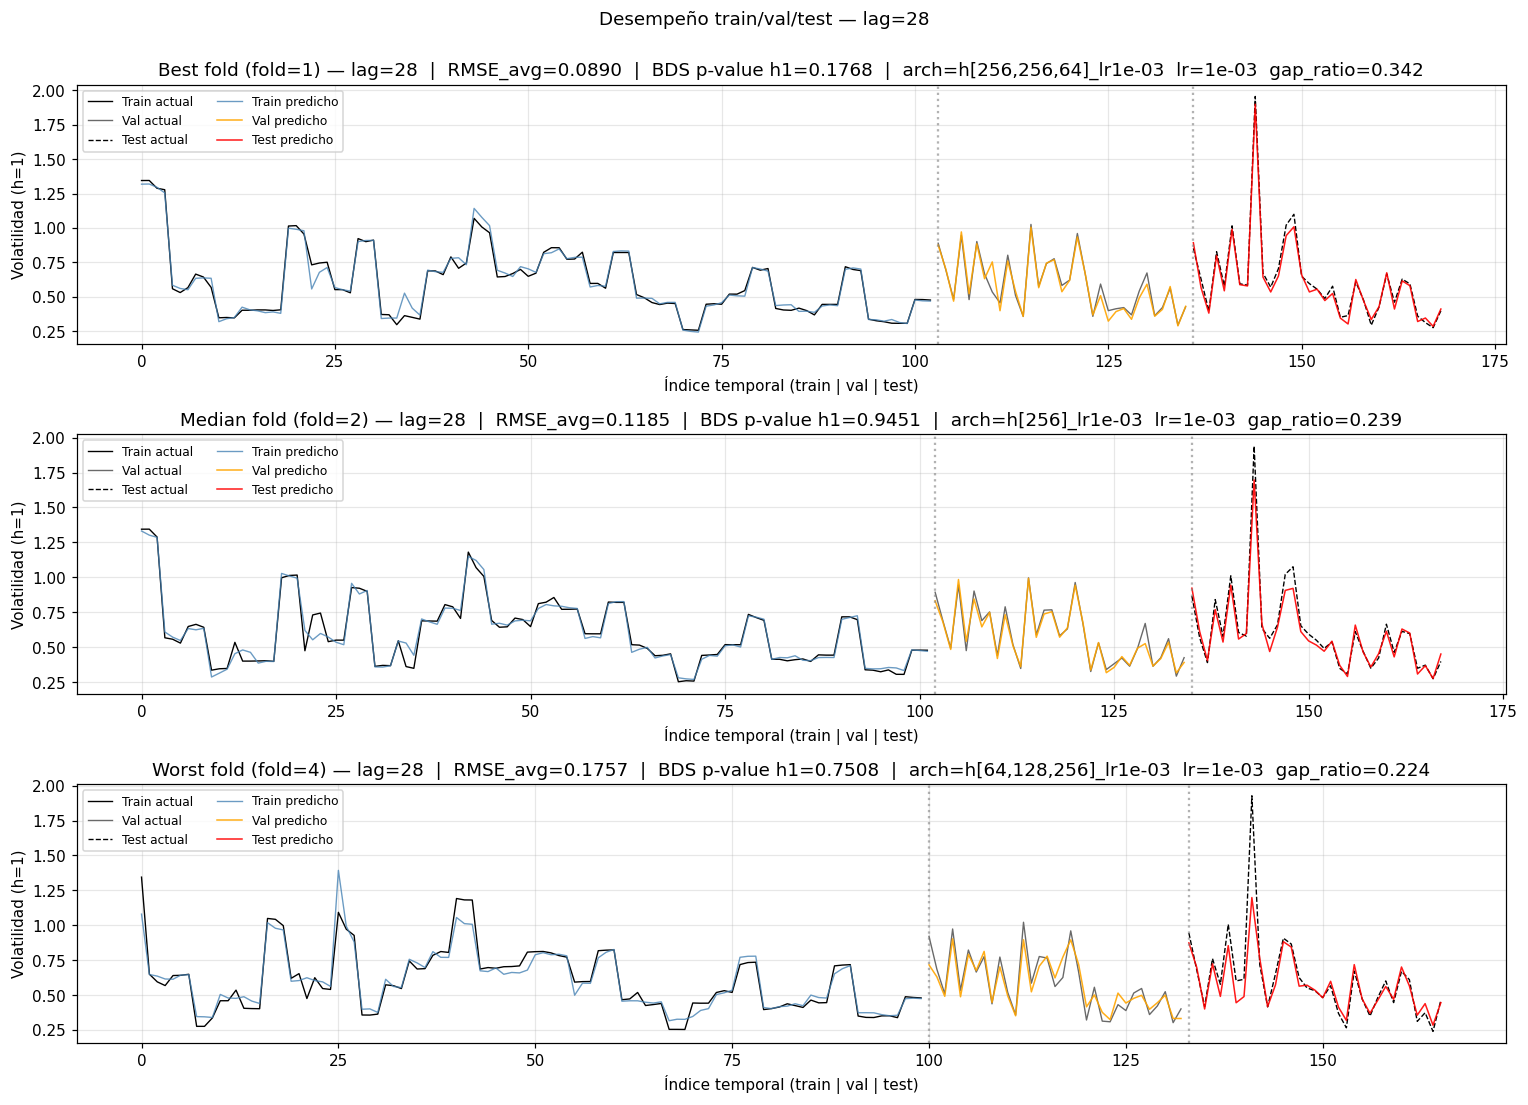

In [8]:
def rank_folds_by_rmse(results_for_lag):
    """Devuelve (best, median, worst) según RMSE promedio 7-step."""
    rmses = {f: m['rmse'].mean() for f, m in results_for_lag.items()}
    folds_sorted = sorted(rmses, key=rmses.get)
    best   = folds_sorted[0]
    worst  = folds_sorted[-1]
    median = folds_sorted[len(folds_sorted) // 2]
    return best, median, worst, rmses

def plot_fold_segments(ax, m, title):
    """Dibuja en ax las series train/val/test (actual y predicho) concatenadas."""
    y_tr    = m['y_train_true'][:, 0]; yhat_tr = m['y_train_pred'][:, 0]
    y_va    = m['y_val_true'][:, 0];   yhat_va = m['y_val_pred'][:, 0]
    y_te    = m['y_test_true'][:, 0];  yhat_te = m['y_test_pred'][:, 0]

    n_tr, n_va, n_te = len(y_tr), len(y_va), len(y_te)
    idx_tr = np.arange(n_tr)
    idx_va = np.arange(n_tr, n_tr + n_va)
    idx_te = np.arange(n_tr + n_va, n_tr + n_va + n_te)

    # Actuales (tonos de negro/gris para distinguir sin duplicar la entrada del legend)
    ax.plot(idx_tr, y_tr, color='black',   lw=0.9, label='Train actual')
    ax.plot(idx_va, y_va, color='dimgray', lw=0.9, label='Val actual')
    ax.plot(idx_te, y_te, color='black',   lw=0.9, linestyle='--', label='Test actual')
    # Predichos
    ax.plot(idx_tr, yhat_tr, color='steelblue', lw=0.9, alpha=0.8, label='Train predicho')
    ax.plot(idx_va, yhat_va, color='orange',    lw=1.0, alpha=0.9, label='Val predicho')
    ax.plot(idx_te, yhat_te, color='red',       lw=1.0, alpha=0.9, label='Test predicho')
    # Separadores
    ax.axvline(n_tr,        color='gray', ls=':', alpha=0.6)
    ax.axvline(n_tr + n_va, color='gray', ls=':', alpha=0.6)

    ax.set_title(title)
    ax.set_xlabel('Índice temporal (train | val | test)')
    ax.set_ylabel('Volatilidad (h=1)')
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8, loc='upper left', ncol=2)

def _title_extras(m):
    """Devuelve el sufijo cosmético con arch/lr/gap_ratio si nb2 los persistió."""
    bits = []
    if 'best_arch' in m:
        bits.append(f"arch={m['best_arch']}")
    if 'best_lr' in m:
        bits.append(f"lr={m['best_lr']:.0e}")
    if 'gap_ratio' in m:
        bits.append(f"gap_ratio={m['gap_ratio']:.3f}")
    return ('  |  ' + '  '.join(bits)) if bits else ''

for n_lag in LAGS_LIST:
    best_f, median_f, worst_f, rmses = rank_folds_by_rmse(all_results[n_lag])
    fig, axes = plt.subplots(3, 1, figsize=(14, 10))
    for ax, fold, label in zip(axes, [best_f, median_f, worst_f], ['Best', 'Median', 'Worst']):
        m = all_results[n_lag][fold]
        title = (f'{label} fold (fold={fold+1}) — lag={n_lag}  |  '
                 f"RMSE_avg={m['rmse'].mean():.4f}  |  "
                 f"BDS p-value h1={m['bds_pvalue_h1']:.4f}"
                 f"{_title_extras(m)}")
        plot_fold_segments(ax, m, title)
    fig.suptitle(f'Desempeño train/val/test — lag={n_lag}', y=1.00)
    fig.tight_layout()
    fig_path = FIGS_DIR / f'segments_lag{n_lag}.png'
    fig.savefig(fig_path, dpi=120, bbox_inches='tight')
    print(f'Guardado: {fig_path}')
    plt.show()

**Comentario — curvas temporales train/val/test (4 figuras, 3 paneles cada una)**

Cada figura muestra la serie h=1 real vs predicha concatenando los 3 subsets (train, val, test) en orden cronológico, para el mejor/mediano/peor fold del lag. Qué mirar y qué valida la figura:

- **Continuidad del ajuste entre subsets**: si el modelo está bien escalado (StandardScaler fit solo con train), la predicción no debería tener un "salto" artificial al cruzar del train al val o test. En estas figuras se ve que la transición es fluida — buena señal del pipeline.
- **Best fold**: predicción (roja) muy cerca de real (negra) en test, tracking amplitud y timing.
- **Median fold**: seguimiento correcto en forma pero atenuación en amplitud (el modelo aplana los picos, subestima la vol extrema).
- **Worst fold**: la predicción se despega sostenidamente en tramos del test. Para lag 7, esto es el Fold 5 con régimen 2024-2025 — consistente con el BDS que detectó no-iid en ese fold.

Estas 4 figuras (`segments_lag{7,14,21,28}.png`) son **las piezas visuales más fuertes** del reporte final: comunican en un vistazo la calidad del ajuste y sus limitaciones. Una figura vale más que 10 tablas de métricas.

## 7. RMSE por fold

Una curva por tamaño de lag mostrando el RMSE promedio (7-step) de cada fold. 

Guardado: figs\rmse_por_fold.png


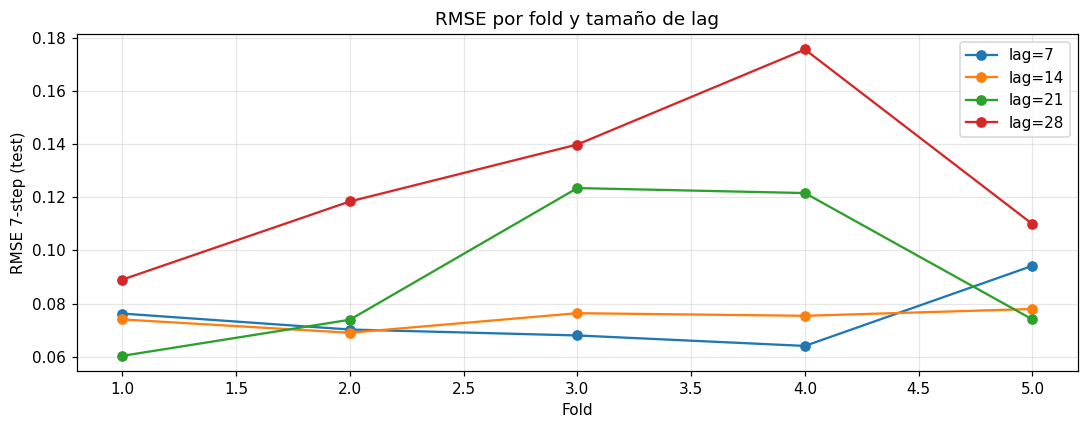

In [9]:
fig, ax = plt.subplots(figsize=(10, 4))
for n_lag in LAGS_LIST:
    rmses_folds = [all_results[n_lag][f]['rmse'].mean() for f in all_results[n_lag]]
    ax.plot(range(1, len(rmses_folds) + 1), rmses_folds, marker='o', label=f'lag={n_lag}')
ax.set_xlabel('Fold')
ax.set_ylabel('RMSE 7-step (test)')
ax.set_title('RMSE por fold y tamaño de lag')
ax.grid(alpha=0.3); ax.legend()
fig.tight_layout()
fig_path = FIGS_DIR / 'rmse_por_fold.png'
fig.savefig(fig_path, dpi=120, bbox_inches='tight')
print(f'Guardado: {fig_path}')
plt.show()

**Comentario — RMSE por fold (diagnóstico cross-lag)**

Replica la figura de nb2 cell 26 pero con residuos recalculados sobre `all_results` (mismos números). Refuerza tres puntos:

1. Lag 7 y 14 se superponen salvo en Fold 5 (lag 7 se dispara).
2. Lag 28 es sistemáticamente el peor en 4 de 5 folds.
3. Fold 4 del lag 28 (0.176) es el outlier global del experimento.


## 8. RMSE promedio por horizonte (7 puntos)

Una línea por tamaño de lag con 7 puntos: RMSE promedio (entre folds) para cada horizonte `h = 1, 2, …, 7`. El error debe **crecer** con el horizonte; si no lo hiciera, habría que sospechar data leakage.

Guardado: figs\rmse_por_horizonte.png


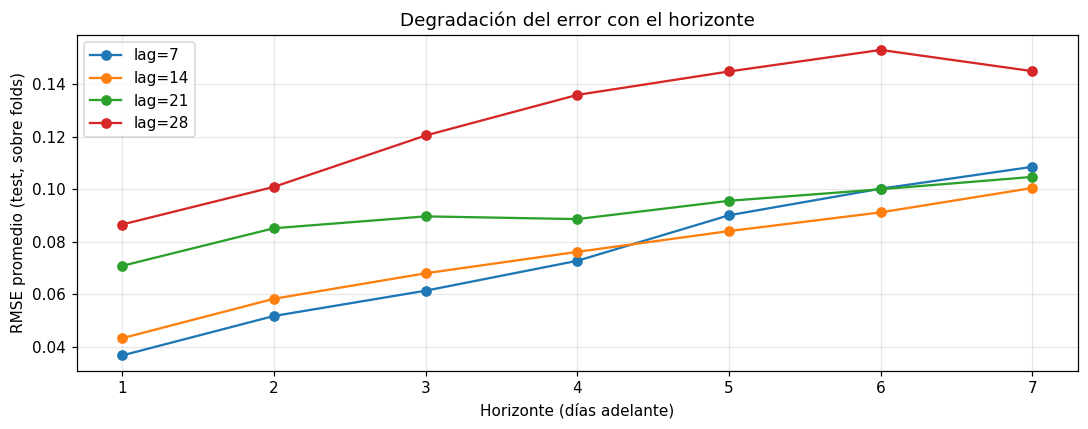

In [10]:
fig, ax = plt.subplots(figsize=(10, 4))
for n_lag in LAGS_LIST:
    rmse_h = np.mean([all_results[n_lag][f]['rmse'] for f in all_results[n_lag]], axis=0)
    ax.plot(range(1, N_STEPS_FORECAST + 1), rmse_h, marker='o', label=f'lag={n_lag}')
ax.set_xlabel('Horizonte (días adelante)')
ax.set_ylabel('RMSE promedio (test, sobre folds)')
ax.set_title('Degradación del error con el horizonte')
ax.grid(alpha=0.3); ax.legend()
fig.tight_layout()
fig_path = FIGS_DIR / 'rmse_por_horizonte.png'
fig.savefig(fig_path, dpi=120, bbox_inches='tight')
print(f'Guardado: {fig_path}')
plt.show()

**Comentario — degradación del RMSE por horizonte**

Cuatro curvas monotónicamente crecientes de h_1 a h_7. Confirma **ausencia de data leakage** (si el error bajara con el horizonte o fuera plano, sería un bug del pipeline de features/escalado).

El orden vertical de las curvas (28 > 21 > 7 ≈ 14) sostiene la jerarquía del resumen: ventanas largas = más error en todos los horizontes, no solo en el promedio.

Observación cualitativa: la **pendiente** de la degradación es similar entre lags (todas más o menos paralelas). Implicación: no hay un lag específico que se degrade "más rápido" — la dificultad intrínseca de proyectar al futuro es universal, el offset inicial (h_1) es lo que marca la diferencia.



In [11]:
best_lag = int(final_summary['avg_RMSE_test'].idxmin())
row = final_summary.loc[best_lag]
print(f'Lag ganador por RMSE promedio: {best_lag}')
print(f"  avg_RMSE_test  = {row['avg_RMSE_test']:.4f}")
print(f"  avg_MAE_test   = {row['avg_MAE_test']:.4f}")
print(f"  avg_MAPE_test  = {row['avg_MAPE_test']:.4f}")
print(f"  avg_BDS_pval   = {row['avg_BDS_pval']:.4f}")
print(f"  pct_folds_iid  = {row['pct_folds_iid_%']:.1f} %")

# Lag ganador por BDS (más folds con residuos iid)
best_lag_bds = int(final_summary['pct_folds_iid_%'].idxmax())
print(f'\nLag ganador por BDS (mayor %% de folds iid): {best_lag_bds}')



Lag ganador por RMSE promedio: 7
  avg_RMSE_test  = 0.0745
  avg_MAE_test   = 0.0494
  avg_MAPE_test  = 9.0690
  avg_BDS_pval   = 0.4513
  pct_folds_iid  = 80.0 %

Lag ganador por BDS (mayor %% de folds iid): 14
